In [ ]:
# The SMOTE (Synthetic Minority Over-sampling Technique) technique:

In [4]:
# Install Necessary Libraries:
# pip install pandas scikit-learn imbalanced-learn matplotlib


In [15]:
 # Import Libraries:
import pandas as pd
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential, Model
from keras.layers import Dense, LeakyReLU, BatchNormalization, Input
from keras.optimizers import Adam

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

In [5]:
# Load the Dataset:
url = "https://storage.googleapis.com/qwasar-public/track-ds/creditcard.csv"
data = pd.read_csv(url)

In [6]:
# Explore and Preprocess the Data:
# Check the first few rows
print(data.head())

# Check for missing values
print(data.isnull().sum())

# Get a summary of the dataset
print(data.describe())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [7]:
# Separate Features and Target Variable:
# Define X (features) and y (target)
X = data.drop('Class', axis=1)  # Drop the target column
y = data['Class']  # Target column (fraudulent or not)

In [10]:
#  Standardize the Data (Optional but Recommended):
# Standardize the features (important for some ML models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:
# I. Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Original class distribution:", y_train.value_counts())
print("Resampled class distribution:", y_train_smote.value_counts())

C:\Users\pavle\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\pavle\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Original class distribution: Class
0    227451
1       394
Name: count, dtype: int64
Resampled class distribution: Class
0    227451
1    227451
Name: count, dtype: int64


In [13]:
# Train a Model on the Augmented Data:
# Initialize a classifier (Random Forest in this case)
classifier = RandomForestClassifier(random_state=42)

# Train the model on the resampled (SMOTE) data
classifier.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56855     9]
 [   17    81]]


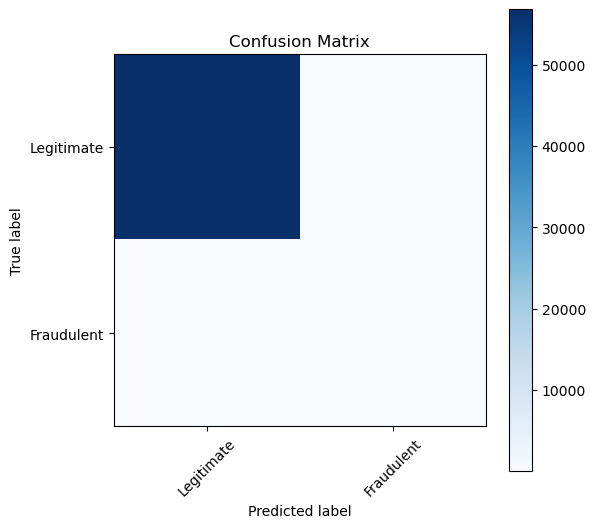

In [20]:
# Evaluate the Model:
# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot the Confusion Matrix (Optional for better visualization)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = ['Legitimate', 'Fraudulent']
tick_marks = range(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


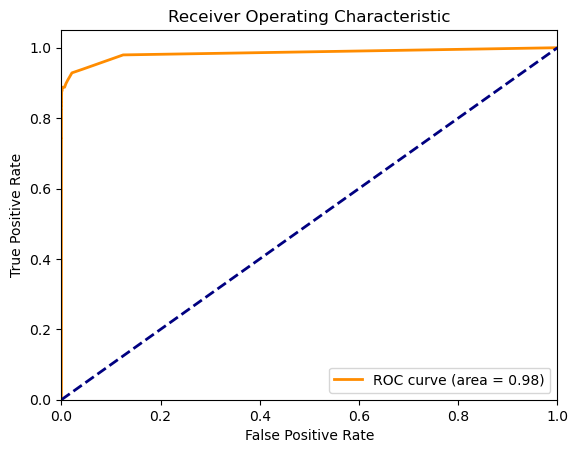

In [21]:
# Visualize the Performance:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, classifier.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# II. Adaptive Synthetic (ADASYN):

In [16]:
# 1.Apply ADASYN to Balance the Classes:
# Initialize ADASYN
adasyn = ADASYN(sampling_strategy='auto', random_state=42, n_neighbors=5)

# Apply ADASYN to the training data
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Check the new class distribution after resampling
print("Original class distribution:", y_train.value_counts())
print("Resampled class distribution:", y_train_adasyn.value_counts())


C:\Users\pavle\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\pavle\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The ADASYN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Original class distribution: Class
0    227451
1       394
Name: count, dtype: int64
Resampled class distribution: Class
1    227458
0    227451
Name: count, dtype: int64


In [17]:
# 2. Train a Model on the Augmented Data:
# Initialize a classifier (Random Forest in this case)
classifier = RandomForestClassifier(random_state=42)

# Train the model on the resampled (ADASYN) data
classifier.fit(X_train_adasyn, y_train_adasyn)


RandomForestClassifier(random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56855     9]
 [   17    81]]


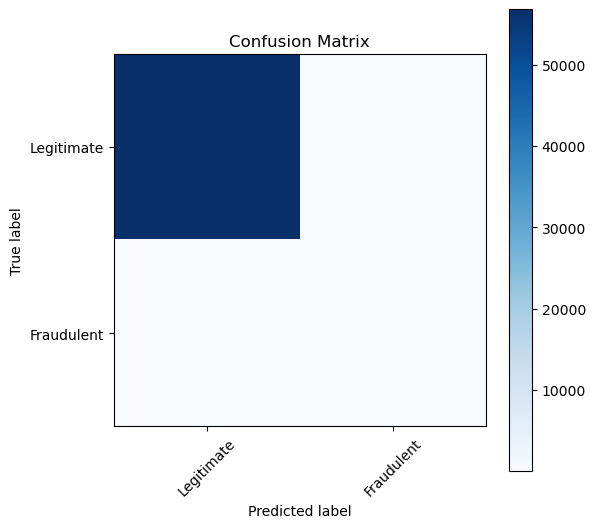

In [18]:
# 3. Evaluate the Model:
# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model using classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix (Optional for better visualization)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = ['Legitimate', 'Fraudulent']
tick_marks = range(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


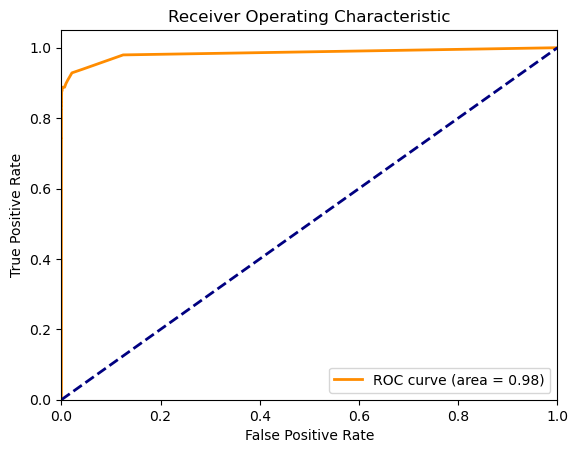

In [19]:
# 4.Visualize the Performance:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, classifier.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
#  III. Generative Adversarial Networks (GANs):

In [ ]:
# Load the dataset
url = "https://storage.googleapis.com/qwasar-public/track-ds/creditcard.csv"
data = pd.read_csv(url)

# Check the first few rows
print(data.head())

# Separate features (X) and target variable (y)
X = data.drop('Class', axis=1)  # Features (Time, V1 to V28, Amount)
y = data['Class']  # Target (fraudulent or not)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Only use the fraudulent class (Class == 1) for training the GAN
X_train_fraud = X_train[y_train == 1]
print("Number of fraudulent samples in training set:", X_train_fraud.shape[0])


In [ ]:
# 2. Build the GAN Model:
# 2.1. Define the Generator Model:
def build_generator(latent_dim, input_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(input_dim, activation='tanh'))
    
    noise = Input(shape=(latent_dim,))
    generated_data = model(noise)
    
    return Model(noise, generated_data)

# 2.2. Define the Discriminator Model:
def build_discriminator(input_dim):
    model = Sequential()
    model.add(Dense(512, input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(128))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    data = Input(shape=(input_dim,))
    validity = model(data)
    
    return Model(data, validity)
# 2.3. Combine the Generator and Discriminator into a GAN:
def build_gan(generator, discriminator):
    # Make the discriminator non-trainable during the GAN training
    discriminator.trainable = False
    
    # The GAN model takes in noise and outputs the probability of the data being real
    noise = Input(shape=(latent_dim,))
    generated_data = generator(noise)
    validity = discriminator(generated_data)
    
    return Model(noise, validity)


In [ ]:
# 3. Compile the Models:
# Set dimensions
latent_dim = 100  # Dimensionality of the random noise
input_dim = X_train_fraud.shape[1]  # Number of features in the data

# Build and compile the discriminator
discriminator = build_discriminator(input_dim)
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])

# Build the generator
generator = build_generator(latent_dim, input_dim)

# Build and compile the GAN
gan = build_gan(generator, discriminator)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))


In [ ]:
# 4. Train the GAN:
# Training the GAN
def train_gan(generator, discriminator, gan, data, epochs=10000, batch_size=32, sample_interval=1000):
    half_batch = batch_size // 2
    
    # Create an array to store the training losses
    d_losses = []
    g_losses = []
    
    # Training loop
    for epoch in range(epochs):
        # Train the discriminator
        # Select a random half-batch of real samples
        idx = np.random.randint(0, data.shape[0], half_batch)
        real_data = data[idx]
        
        # Generate a half-batch of fake samples
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_data = generator.predict(noise)
        
        # Train the discriminator on real and fake data
        d_loss_real = discriminator.train_on_batch(real_data, np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_data, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        
        # Train the generator (via the GAN model)
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))
        
        # Store the losses
        d_losses.append(d_loss[0])
        g_losses.append(g_loss)
        
        # Print progress at intervals
        if epoch % sample_interval == 0:
            print(f"{epoch} [D loss: {d_loss[0]}] [G loss: {g_loss}]")
    
    return d_losses, g_losses

# Train the GAN
d_losses, g_losses = train_gan(generator, discriminator, gan, X_train_fraud, epochs=10000, batch_size=64, sample_interval=1000)


In [ ]:
# 5. Generate Synthetic Data:
# Generate synthetic fraudulent data
noise = np.random.normal(0, 1, (X_train_fraud.shape[0], latent_dim))
generated_data = generator.predict(noise)

# Reverse the scaling of the generated data
generated_data_rescaled = scaler.inverse_transform(generated_data)

# Create a DataFrame of the generated data
generated_data_df = pd.DataFrame(generated_data_rescaled, columns=X.columns)
print(generated_data_df.head())


In [ ]:
# 6. Evaluate the Synthetic Data: